In [1]:
!pip install yfinance matplotlib pandas numpy scikit-learn torch

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [5]:
# Date range: 2010-01-01 to 2023-12-31 (as per assignment description)
ticker = "SPY"
start_date = "2010-01-01"
end_date = "2023-12-31"

print(f"Downloading {ticker} data from {start_date} to {end_date}...")
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

if isinstance(data.columns, pd.MultiIndex):
    try:
        prices = data[('Adj Close', ticker)]
    except KeyError:
        prices = data['Adj Close']
else:
    prices = data['Adj Close']

print(f"Data downloaded. Total trading days: {len(prices)}")

[*********************100%***********************]  1 of 1 completed

Data downloaded. Total trading days: 3522


In [6]:
def calculate_log_returns(prices):
    prices_arr = np.array(prices)
    log_returns = np.log(prices_arr[1:] / prices_arr[:-1])
    return log_returns

def create_sequences(data, seq_length=64):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        seq = data[i : i + seq_length]
        sequences.append(seq)
    return np.array(sequences)

In [7]:
log_returns = calculate_log_returns(prices)
SEQ_LENGTH = 64
sequences = create_sequences(log_returns, seq_length=SEQ_LENGTH)

print(f"Log-returns shape: {log_returns.shape}")
print(f"Sequences shape: {sequences.shape}")

Log-returns shape: (3521,)
Sequences shape: (3458, 64)


In [9]:
# Standardization
scaler = StandardScaler()

sequences_flat = sequences.flatten().reshape(-1, 1)
sequences_scaled_flat = scaler.fit_transform(sequences_flat)
sequences_scaled = sequences_scaled_flat.reshape(sequences.shape)

X_tensor = torch.tensor(sequences_scaled, dtype=torch.float32).unsqueeze(-1)

# Chronological Split (90% Train, 10% Test)
split_idx = int(len(X_tensor) * 0.9)

train_data = X_tensor[:split_idx]
test_data = X_tensor[split_idx:]

print(f"Total samples: {len(X_tensor)}")
print(f"Train samples (90%): {len(train_data)}")
print(f"Test samples (10%): {len(test_data)}")

# Create DataLoaders
BATCH_SIZE = 512

train_dataset = TensorDataset(train_data)
test_dataset = TensorDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Total samples: 3458
Train samples (90%): 3112
Test samples (10%): 346


In [10]:
# Define the Flow Matching Model
import torch.nn as nn

class VectorFieldNetwork(nn.Module):
    def __init__(self, seq_length=64, hidden_dim=512):
        super().__init__()
        self.input_dim = seq_length + 1
        self.output_dim = seq_length

        # Simple MLP Architecture
        self.net = nn.Sequential(
            nn.Linear(self.input_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),

            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),

            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),

            nn.Linear(hidden_dim, self.output_dim)
        )

    def forward(self, x, t):
        x_flat = x.view(x.size(0), -1)

        model_input = torch.cat([x_flat, t], dim=1)

        # Forward pass
        output = self.net(model_input)

        # Reshape back to [batch_size, seq_len, 1]
        return output.view(x.size(0), -1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VectorFieldNetwork(seq_length=64).to(device)

print(f"Model initialized on {device}")

Model initialized on cuda


In [12]:
# Training Loop Implementation
LR = 2e-4
EPOCHS = 100
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for x1_batch in train_loader:
        x1 = x1_batch[0].to(device)
        batch_size = x1.size(0)

        t = torch.rand(batch_size, 1, device=device)

        x0 = torch.randn_like(x1)

        t_broadcast = t.view(batch_size, 1, 1)
        xt = (1 - t_broadcast) * x0 + t_broadcast * x1

        target_v = x1 - x0

        # Model Prediction
        pred_v = model(xt, t)

        # Loss Calculation
        loss = torch.mean((pred_v - target_v) ** 2)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)

    # Validation Step
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for x1_test in test_loader:
            x1 = x1_test[0].to(device)
            batch_size = x1.size(0)

            # Same process for validation
            t = torch.rand(batch_size, 1, device=device)
            x0 = torch.randn_like(x1)
            t_broadcast = t.view(batch_size, 1, 1)
            xt = (1 - t_broadcast) * x0 + t_broadcast * x1
            target_v = x1 - x0

            pred_v = model(xt, t)
            loss = torch.mean((pred_v - target_v) ** 2)
            val_batch_losses.append(loss.item())

    avg_test_loss = np.mean(val_batch_losses)
    test_losses.append(avg_test_loss)


    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("Training complete!")

Epoch [1/100] | Train Loss: 1.554726 | Test Loss: 1.886074
Epoch [2/100] | Train Loss: 1.552262 | Test Loss: 1.895941
Epoch [3/100] | Train Loss: 1.545161 | Test Loss: 1.876477
Epoch [4/100] | Train Loss: 1.573267 | Test Loss: 1.866036
Epoch [5/100] | Train Loss: 1.548840 | Test Loss: 1.839360
Epoch [6/100] | Train Loss: 1.534038 | Test Loss: 1.884062
Epoch [7/100] | Train Loss: 1.486178 | Test Loss: 1.867187
Epoch [8/100] | Train Loss: 1.499480 | Test Loss: 1.852566
Epoch [9/100] | Train Loss: 1.505631 | Test Loss: 1.838779
Epoch [10/100] | Train Loss: 1.605724 | Test Loss: 1.872592
Epoch [11/100] | Train Loss: 1.535126 | Test Loss: 1.840130
Epoch [12/100] | Train Loss: 1.518338 | Test Loss: 1.854982
Epoch [13/100] | Train Loss: 1.523534 | Test Loss: 1.838915
Epoch [14/100] | Train Loss: 1.541193 | Test Loss: 1.864514
Epoch [15/100] | Train Loss: 1.518493 | Test Loss: 1.811418
Epoch [16/100] | Train Loss: 1.560336 | Test Loss: 1.884312
Epoch [17/100] | Train Loss: 1.534445 | Test Loss

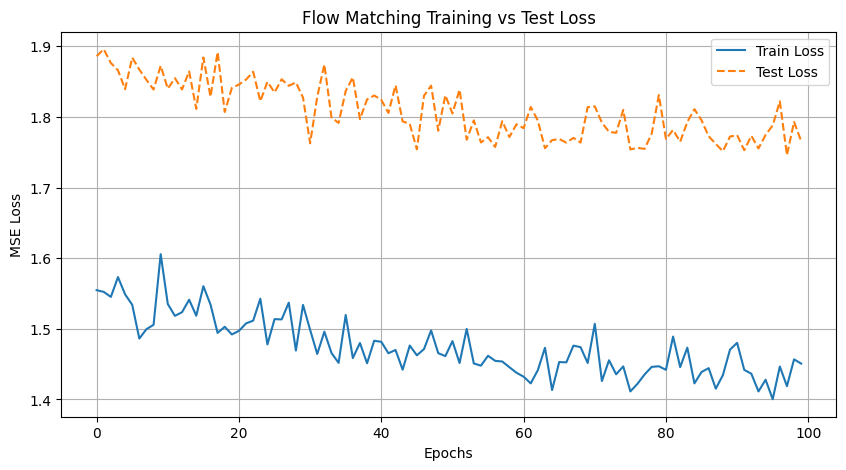

Final Train Loss: 1.450692
Final Test Loss: 1.765697
Gap: 0.315006


In [13]:
# Plot Training and Test Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Flow Matching Training vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()

# Calculate final gap
final_gap = abs(train_losses[-1] - test_losses[-1])
print(f"Final Train Loss: {train_losses[-1]:.6f}")
print(f"Final Test Loss: {test_losses[-1]:.6f}")
print(f"Gap: {final_gap:.6f}")

In [14]:
# Synthetic Data Generation via ODE Solver

def euler_ode_solver(model, shape, steps=100, device='cuda'):
    model.eval()
    x = torch.randn(shape, device=device)

    dt = 1.0 / steps
    trajectory = [x.cpu().numpy()]

    with torch.no_grad():
        for i in range(steps):
            t_value = i / steps
            t = torch.full((shape[0], 1), t_value, device=device)

            velocity = model(x, t)

            x = x + velocity * dt
    return x

# Generate Synthetic Data
NUM_SAMPLES = 5
SEQ_LENGTH = 64
STEPS = 100

print(f"Generating {NUM_SAMPLES} synthetic samples with {STEPS} Euler steps...")
generated_data_norm = euler_ode_solver(model, shape=(NUM_SAMPLES, SEQ_LENGTH, 1), steps=STEPS, device=device)

print("Generation complete.")
print(f"Generated Data Shape: {generated_data_norm.shape}")

Generating 5 synthetic samples with 100 Euler steps...
Generation complete.
Generated Data Shape: torch.Size([5, 64, 1])


In [15]:
# Denormalize data to original scale

gen_flat = generated_data_norm.cpu().numpy().reshape(-1, 1)
generated_data_denorm = scaler.inverse_transform(gen_flat).reshape(NUM_SAMPLES, SEQ_LENGTH)

real_samples_norm = next(iter(test_loader))[0][:NUM_SAMPLES].cpu().numpy()
real_flat = real_samples_norm.reshape(-1, 1)
real_samples_denorm = scaler.inverse_transform(real_flat).reshape(NUM_SAMPLES, SEQ_LENGTH)

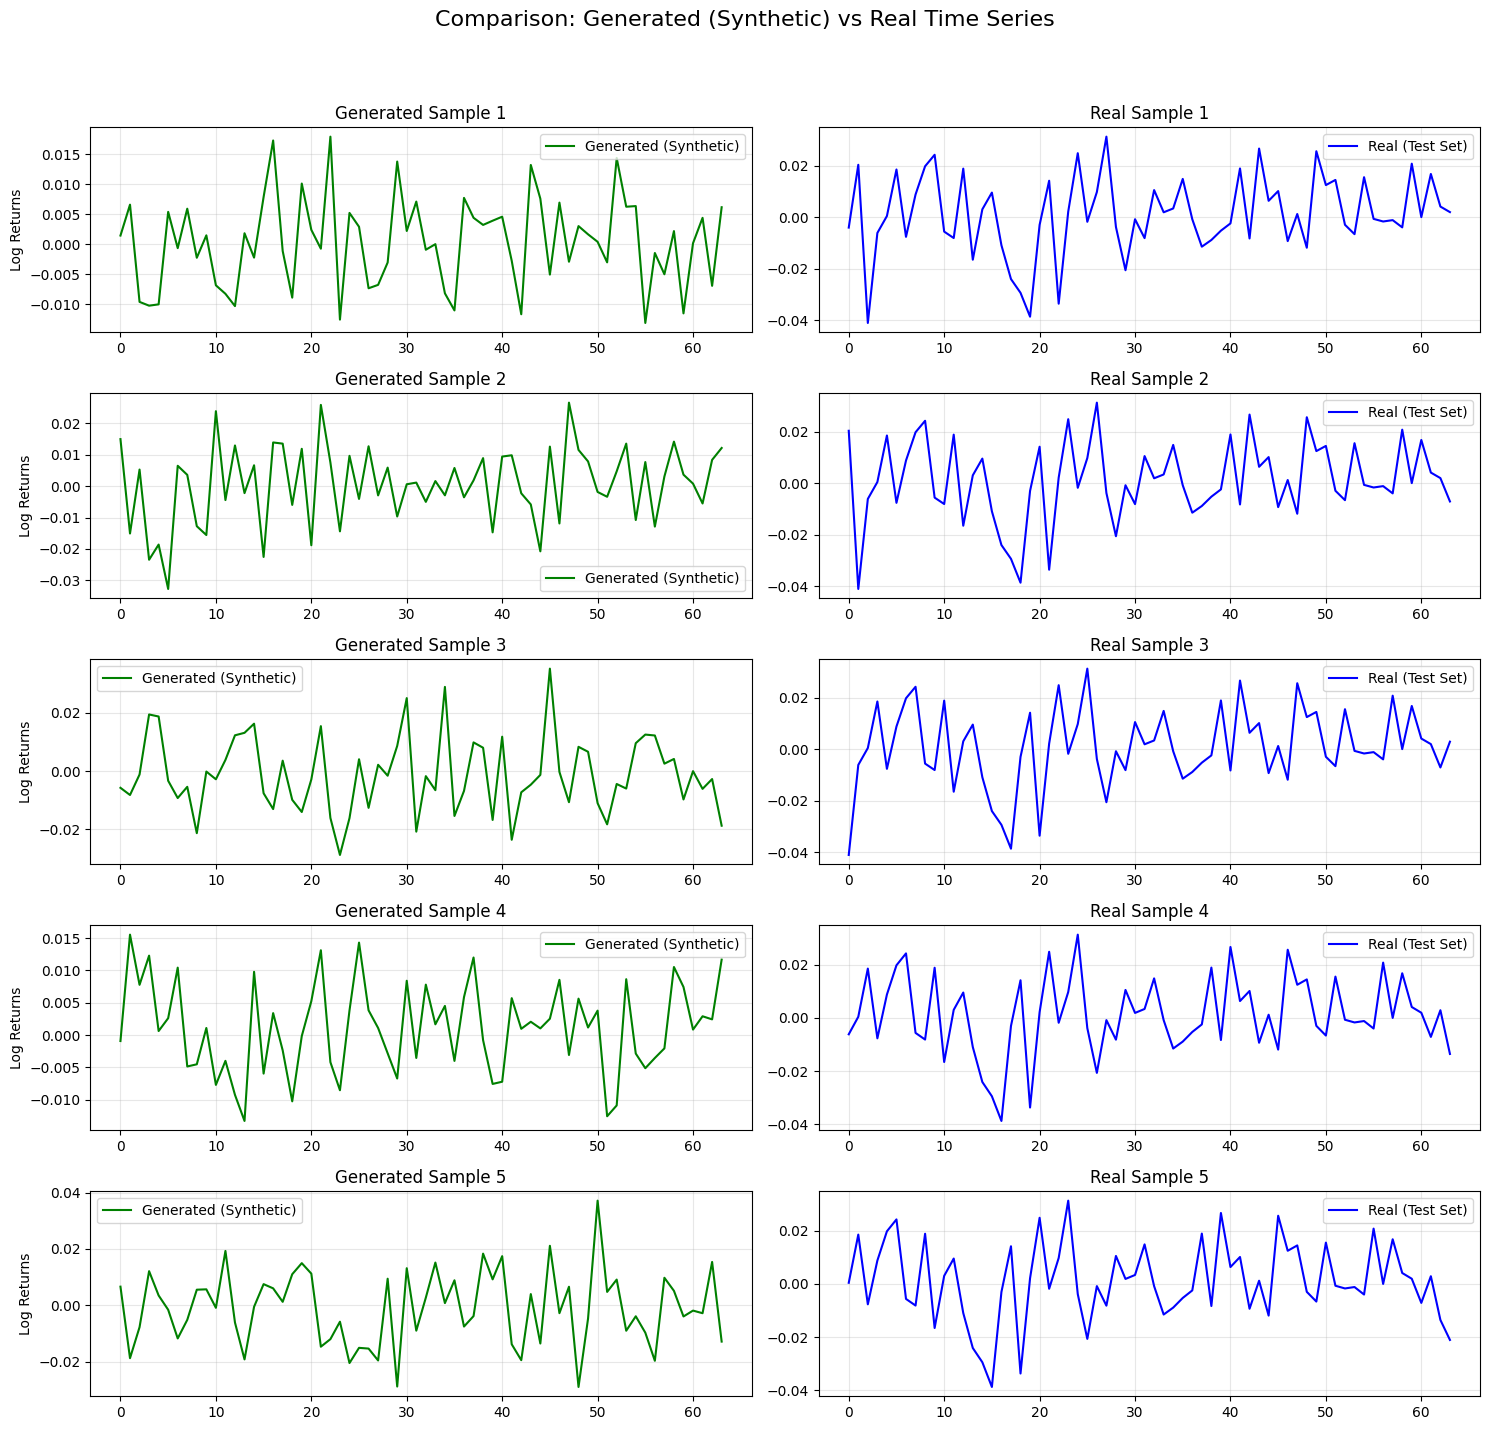

In [16]:
# Visualize Generated Time Series
fig, axes = plt.subplots(NUM_SAMPLES, 2, figsize=(15, 3 * NUM_SAMPLES))
fig.suptitle('Comparison: Generated (Synthetic) vs Real Time Series', fontsize=16)

for i in range(NUM_SAMPLES):
    axes[i, 0].plot(generated_data_denorm[i], color='green', label='Generated (Synthetic)')
    axes[i, 0].set_title(f'Generated Sample {i+1}')
    axes[i, 0].set_ylabel('Log Returns')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].legend()

    axes[i, 1].plot(real_samples_denorm[i], color='blue', label='Real (Test Set)')
    axes[i, 1].set_title(f'Real Sample {i+1}')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

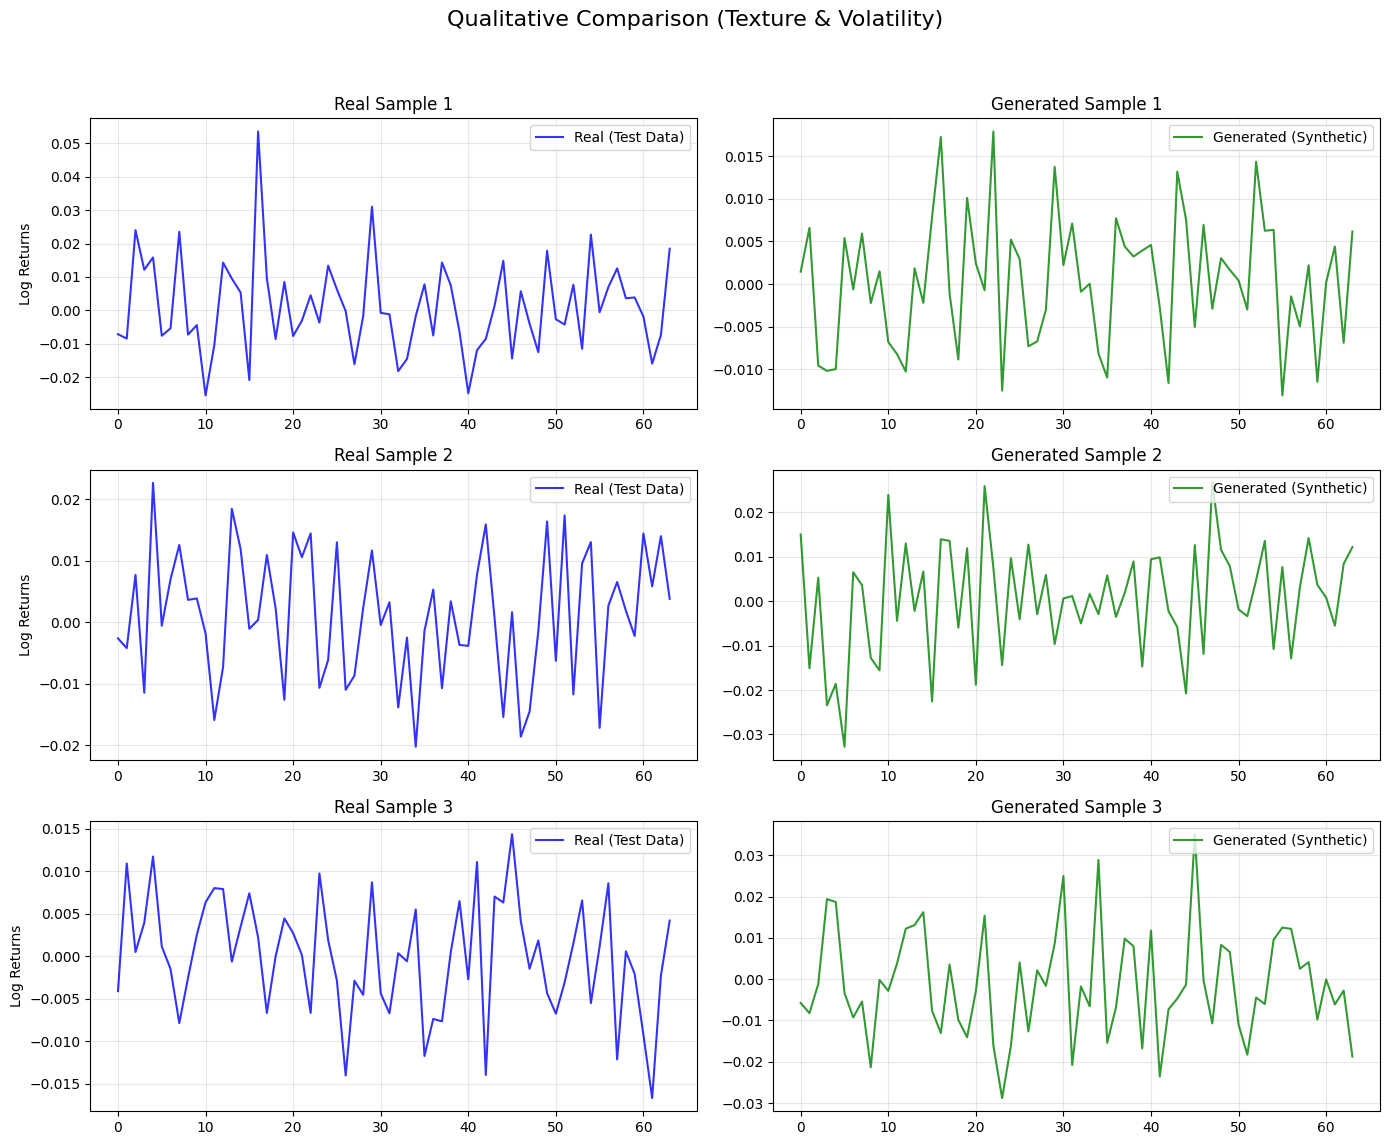

In [17]:
# Qualitative Comparison of Real vs Generated Patterns

num_display = 3
indices = np.random.choice(len(test_data), num_display, replace=False)

fig, axes = plt.subplots(num_display, 2, figsize=(14, 4 * num_display))
fig.suptitle('Qualitative Comparison (Texture & Volatility)', fontsize=16)

for i in range(num_display):
    real_seq = test_data[indices[i]].cpu().numpy().flatten()
    real_seq_denorm = scaler.inverse_transform(real_seq.reshape(-1, 1)).flatten()

    gen_idx = i % len(generated_data_denorm)
    gen_seq_denorm = generated_data_denorm[gen_idx]

    # Plot Real
    axes[i, 0].plot(real_seq_denorm, color='blue', alpha=0.8, label='Real (Test Data)')
    axes[i, 0].set_title(f'Real Sample {i+1}')
    axes[i, 0].set_ylabel('Log Returns')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].legend(loc='upper right')

    # Plot Generated
    axes[i, 1].plot(gen_seq_denorm, color='green', alpha=0.8, label='Generated (Synthetic)')
    axes[i, 1].set_title(f'Generated Sample {i+1}')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generated data points: 64000
Real data points: 22144


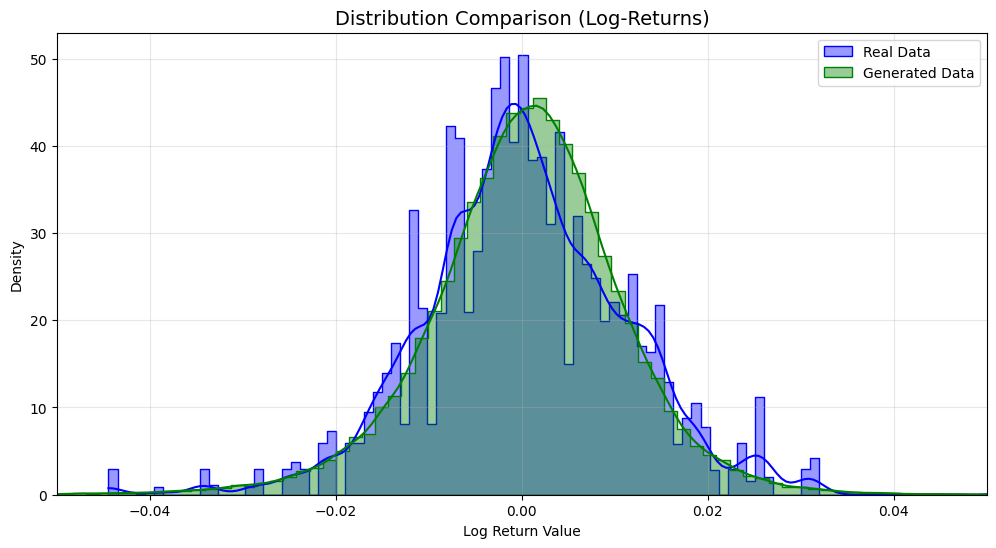

In [18]:
# Distribution Comparison
import seaborn as sns

LARGE_BATCH_SIZE = 1000
gen_large_norm = euler_ode_solver(model, shape=(LARGE_BATCH_SIZE, SEQ_LENGTH, 1), steps=50, device=device) # Reduced steps for speed

gen_large_flat = gen_large_norm.cpu().numpy().flatten().reshape(-1, 1)
gen_large_denorm = scaler.inverse_transform(gen_large_flat).flatten()

real_large_flat = test_data.cpu().numpy().flatten().reshape(-1, 1)
real_large_denorm = scaler.inverse_transform(real_large_flat).flatten()

print(f"Generated data points: {len(gen_large_denorm)}")
print(f"Real data points: {len(real_large_denorm)}")

plt.figure(figsize=(12, 6))
sns.histplot(real_large_denorm, bins=100, kde=True, stat="density",
             color='blue', label='Real Data', alpha=0.4, element="step")
sns.histplot(gen_large_denorm, bins=100, kde=True, stat="density",
             color='green', label='Generated Data', alpha=0.4, element="step")

plt.title('Distribution Comparison (Log-Returns)', fontsize=14)
plt.xlabel('Log Return Value')
plt.ylabel('Density')
plt.xlim(-0.05, 0.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Basic Statistical Evaluation
import pandas as pd

def calculate_stats(data, label):
    mean_val = np.mean(data)
    var_val = np.var(data)
    vol_val = np.std(data)

    return {
        "Dataset": label,
        "Mean": mean_val,
        "Variance": var_val,
        "Volatility (Std)": vol_val
    }

stats_real = calculate_stats(real_large_denorm, "Real Data")
stats_gen = calculate_stats(gen_large_denorm, "Generated Data")

df_stats = pd.DataFrame([stats_real, stats_gen])

vol_real = stats_real["Volatility (Std)"]
vol_gen = stats_gen["Volatility (Std)"]
vol_error = abs(vol_gen - vol_real) / vol_real * 100

print("--- Statistical Comparison ---")
print(df_stats.to_string(index=False))
print("-" * 40)
print(f"Volatility Relative Error: {vol_error:.2f}%")

--- Statistical Comparison ---
       Dataset     Mean  Variance  Volatility (Std)
     Real Data 0.000400  0.000128          0.011293
Generated Data 0.000438  0.000108          0.010391
----------------------------------------
Volatility Relative Error: 7.99%



--- Results ---
1. Sliced Wasserstein Distance (SWD): 0.000005
2. Autocorrelation MSE: 0.005134


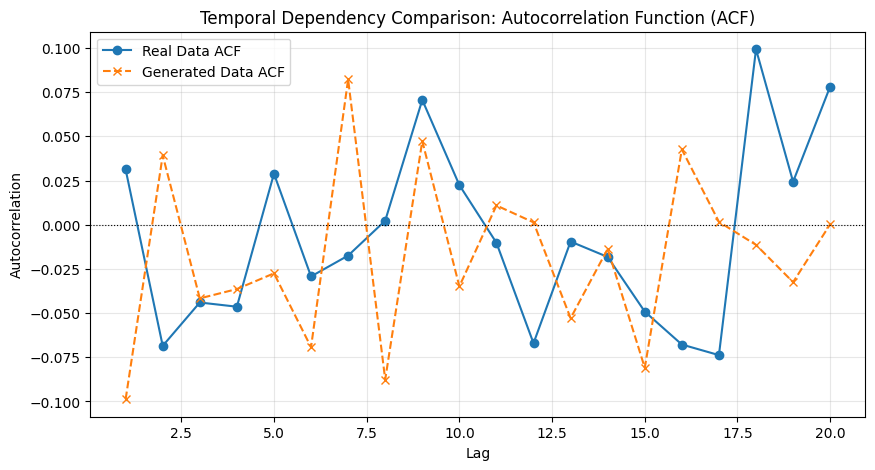

In [10]:
# Advanced Evaluation
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sliced_wasserstein_distance(x_real, x_gen, num_projections=1000, device='cpu'):
    dim = x_real.shape[1]

    projections = torch.randn((num_projections, dim), device=device)
    projections = projections / torch.sqrt(torch.sum(projections**2, dim=1, keepdim=True))

    proj_real = torch.matmul(x_real, projections.t())
    proj_gen = torch.matmul(x_gen, projections.t())

    proj_real_sorted, _ = torch.sort(proj_real, dim=0)
    proj_gen_sorted, _ = torch.sort(proj_gen, dim=0)

    swd = torch.mean((proj_real_sorted - proj_gen_sorted)**2)
    return swd.item()

if 'SEQ_LENGTH' not in locals():
    SEQ_LENGTH = 64

try:
    tensor_real = torch.tensor(real_large_denorm.reshape(-1, SEQ_LENGTH), dtype=torch.float32).to(device)
    tensor_gen = torch.tensor(gen_large_denorm.reshape(-1, SEQ_LENGTH), dtype=torch.float32).to(device)

    min_samples = min(tensor_real.size(0), tensor_gen.size(0))

    tensor_real_swd = tensor_real[:min_samples]
    tensor_gen_swd = tensor_gen[:min_samples]

    swd_score = sliced_wasserstein_distance(tensor_real_swd, tensor_gen_swd, device=device)

    def compute_autocorrelation(data, max_lag=20):
        n_samples, seq_len = data.shape
        acf_curve = np.zeros(max_lag)

        for i in range(n_samples):
            series = data[i]
            mean = np.mean(series)
            var = np.var(series)
            if var < 1e-9: continue

            for lag in range(1, max_lag + 1):
                cov = np.mean((series[:-lag] - mean) * (series[lag:] - mean))
                corr = cov / var
                acf_curve[lag-1] += corr

        return acf_curve / n_samples

    max_lag = 20

    data_real_np = tensor_real.cpu().numpy()
    data_gen_np = tensor_gen.cpu().numpy()

    acf_real = compute_autocorrelation(data_real_np, max_lag)
    acf_gen = compute_autocorrelation(data_gen_np, max_lag)

    acf_mse = np.mean((acf_real - acf_gen)**2)

    print(f"\n--- Results ---")
    print(f"1. Sliced Wasserstein Distance (SWD): {swd_score:.6f}")
    print(f"2. Autocorrelation MSE: {acf_mse:.6f}")

    plt.figure(figsize=(10, 5))
    lags = np.arange(1, max_lag + 1)
    plt.plot(lags, acf_real, marker='o', label='Real Data ACF')
    plt.plot(lags, acf_gen, marker='x', label='Generated Data ACF', linestyle='--')
    plt.axhline(0, color='black', linewidth=0.8, linestyle=':')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.title('Temporal Dependency Comparison: Autocorrelation Function (ACF)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except NameError as e:
    print(f"Error: {e}")
    print("Hint: Variables are missing. Please run the RECOVERY CELL first.")
except RuntimeError as e:
    print(f"RuntimeError: {e}")